In [31]:
import numpy as np
import random
import math 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
seed1 = 546

MAX_INT = 32768

generator_uni_i = np.random.default_rng(seed1)
generator_uni_r = np.random.default_rng(seed1 + 100)
generator_norm = np.random.default_rng(seed1 + 200)  
generator_cachy = np.random.default_rng(seed1 + 300)
generator_uni_i_2 = np.random.default_rng(seed1 + 400)


def IntRandom(target: int) -> int:
    if target == 0:
        return 0
    return int(generator_uni_i.integers(0, MAX_INT) % target)

def Random(minimal: float, maximal: float) -> float:
    return generator_uni_r.uniform(0.0, 1.0) * (maximal - minimal) + minimal

def NormRand(mu: float, sigma: float) -> float:
    return generator_norm.normal(0.0, 1.0) * sigma + mu

def CachyRand(mu: float, sigma: float) -> float:
    return generator_cachy.standard_cauchy() * sigma + mu

def test_func(X, dim):
    X = np.array(X)
    y = np.sum(X[:dim]**2)
    return y  

fopt = 0.0

NFEval = 0 # put that back in class - needs Save method back inside


NMBR_OF_RUNS=30
NUM_OF_DUMPS=16
# CHECKPOINTS = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9] # TODO - implement

stepsFEval = np.zeros(NUM_OF_DUMPS)
ResultsArray = np.zeros((1, NMBR_OF_RUNS, NUM_OF_DUMPS+1))   # (f_amount, runs_amount, NUM_OF_DUMPS) - TODO - reimplement as in the rest
LastFEcount = 0
globalBestFit = 0.0
globalBestFitinit = False


dimensionality=10
maxFes = 10000

MIN_ERROR=1e-8
TRIES = 25

def GenerateNextRandUnif(num, Range, Rands, Prohib=None):
    for _ in range(TRIES):
        candidate = IntRandom(Range)
        if candidate not in Rands[:num]:
            Rands[num] = candidate
            break
    else:
        Rands[num] = candidate

def GenerateNextRandUnifOnlyArch(num, Range, Range2, Rands, Prohib=None):
    for _ in range(TRIES):
        candidate = IntRandom(Range2) + Range
        if candidate not in Rands[:num]:
            Rands[num] = candidate
            break
    else:
        Rands[num] = candidate

def CheckGenerated(num, Rands, Prohib):
    if Rands[num] == Prohib:
        return False
    for j in range(num):
        if Rands[j] == Rands[num]:
            return False
    return True

def SaveBestValues(funcN, runNum): # TODO - implementacja w środku
    global LastFEcount
    for stepFEcount in range(LastFEcount, NUM_OF_DUMPS):
        if NFEval == int(stepsFEval[stepFEcount] * maxFes):
            temp = globalBestFit - fopt
            if temp <= MIN_ERROR:
                temp = 0
            ResultsArray[funcN - 1][runNum][stepFEcount] = temp
            LastFEcount = stepFEcount


def FindLimits(Ind, Parent, CurNVars, CurLeft, CurRight):
    for j in range(CurNVars):
        if Ind[j] < CurLeft:
            Ind[j] = Random(CurLeft, CurRight)
        if Ind[j] > CurRight:
            Ind[j] = Random(CurLeft, CurRight)

def IsInfeasible(Ind, CurNVars, CurLeft, CurRight):
    for j in range(CurNVars):
        if (Ind[j] < CurLeft):
            return True
        if (Ind[j] > CurRight):
            return True
    return False


bestSol = np.zeros(dimensionality)


def getIndxOfNearest(popul, popul_size, dimensionality, mean_indiv):
    nearestIndx = 0
    minDist = 1e20
    for indIndx in range(popul_size):
        sqDist = 0
        for dim in range(dimensionality):
            sqDist += (mean_indiv[dim] - popul[indIndx][dim]) ** 2
        if sqDist < minDist:
            minDist = sqDist
            nearestIndx = indIndx
    return nearestIndx


def getMean(popul, popul_size, dimensionality, mean_indiv):
    for dim in range(dimensionality):
        sum = 0
        for indIndx in range(popul_size):
            sum += popul[indIndx][dim]
        mean_indiv[dim] = sum / popul_size


def getDist(ind1, ind2, dimensionality):
    dist=0.0
    for dim in range (dimensionality):
        dist+= pow(ind1[dim]-ind2[dim], 2)
    
    return math.sqrt(dist)


In [32]:
K_MEANS_AS_NEAREST = True
RESAMPLING = True

In [ ]:
class Optimizer():
    def __init__(self, newNInds, newNVars, new_func_num, 
                 newRunN, NewMemSize, NewArchSizeParam, optFit):
        self.optFit = optFit
        self.MemorySize = NewMemSize # Int 
        self.MemoryIter = 0 # Int 
        self.SuccessFilled = 0 # Int 
        self.MemoryCurrentIndex = None # Int 
        self.NVars = newNVars # Int  # dimensions
        self.NInds = newNInds # Int
        self.popSize = self.NInds
        self.NIndsMax = self.NInds # Int 
        self.NIndsMin = 4 # Int 
        self.besti = 0 # Int 

        self.func_num = new_func_num  # Int 
        self.runNum = newRunN # Int 
        self.Generation = 0 # Int 

        self.CurrentArchiveSize = 0 # Int 
        self.F = 0.9 # double 
        self.Cr = 0.9 # double 

        self.bestfit = float('inf') # double 
        
        self.ArchiveSizeParam = NewArchSizeParam # double       
        self.ArchiveSize = self.NIndsMax*self.ArchiveSizeParam # Int 
        self.Int_ArchiveSizeParam = math.ceil(self.ArchiveSizeParam) # Int  

        self.Right = 100 # double 
        self.Left = -100 # double 

        self.Rands = np.zeros(self.NIndsMax) # int* 
        self.Indexes = np.zeros(self.NIndsMax) # int* 
        self.BackIndexes = np.zeros(self.NIndsMax) # int*

        self.Weights = np.zeros(self.NIndsMax) # double* 
        self.Donor = np.zeros(self.NVars) # double* 

        self.FitMass = np.zeros(self.NIndsMax) # double* 
        self.popFitTmp = np.zeros(self.NIndsMax) # double* # TODO - niepotrzeben tu
        self.FitMassCopy = np.zeros(self.NIndsMax) # double*  # TODO - niepotrzeben tu
        self.BestInd = np.zeros(self.NVars) # double* 

        self.tempSuccessCr = np.zeros(self.NIndsMax) # double* 
        self.tempSuccessF = np.zeros(self.NIndsMax) # double* 

        self.FGenerated = np.zeros(self.NIndsMax)  # double* 
        self.CrGenerated = np.zeros(self.NIndsMax) # double* 

        self.MemoryCr = np.full(self.MemorySize, self.Cr) # double* 
        self.MemoryF = np.full(self.MemorySize, self.F) # double* 

        self.FitDelta = np.zeros(self.NIndsMax) # double* 
        self.ArchUsages = np.zeros(self.NIndsMax)  # double* 

        self.Popul = np.zeros((self.NIndsMax, self.NVars)) # double** 
        for i in range(self.NIndsMax):
            for j in range(self.NVars):
                self.Popul[i][j] = Random(self.Left, self.Right)        

        self.PopulTemp = np.zeros((self.NIndsMax, self.NVars)) # double** 
        self.Archive = np.zeros((self.NIndsMax*self.Int_ArchiveSizeParam, self.NVars)) # double** 

        for steps_k in range (15):
            stepsFEval[steps_k] = pow(dimensionality,steps_k/5.0-3.0)
        stepsFEval[15] = 1.0

    def SaveSuccessCrF(self, Cr, F, FitD):
        self.tempSuccessCr[self.SuccessFilled] = Cr
        self.tempSuccessF[self.SuccessFilled] = F
        self.FitDelta[self.SuccessFilled] = FitD
        self.SuccessFilled += 1

    def UpdateMemoryCrF(self):
        if(self.SuccessFilled != 0):
            self.MemoryCr[self.MemoryIter] = self.MeanWL_general(self.tempSuccessCr,self.FitDelta,self.SuccessFilled,2,1)
            self.MemoryF[self.MemoryIter] = self.MeanWL_general(self.tempSuccessF, self.FitDelta,self.SuccessFilled,2,1)
            self.MemoryIter += 1
            if(self.MemoryIter >= self.MemorySize):
                self.MemoryIter = 0
        else:
            self.MemoryF[self.MemoryIter] = 0.5
            self.MemoryCr[self.MemoryIter] = 0.5


    def MeanWL_general(self, Vector, TempWeights, Size, g_p, g_m):
        SumWeight = 0
        SumSquare = 0
        Sum = 0
        for i in range(self.SuccessFilled):
            SumWeight += TempWeights[i]

        for i in range(self.SuccessFilled):
            self.Weights[i] = TempWeights[i]/SumWeight

        for i in range(self.SuccessFilled):
            SumSquare += self.Weights[i]*pow(Vector[i],g_p)

        for i in range(self.SuccessFilled):
            Sum += self.Weights[i]*pow(Vector[i],g_p-g_m)

        if(abs(Sum) > 0.000001):
            return SumSquare/Sum
        else:
            return 0.5


    def CopyToArchive(self, RefusedParent, RefusedFitness):
        if(self.CurrentArchiveSize < self.ArchiveSize):
            for i in range(self.NVars):
                self.Archive[int(self.CurrentArchiveSize)][i] = RefusedParent[i]
            self.CurrentArchiveSize += 1

        elif(self.ArchiveSize > 0):
            RandomNum = int(random.randint(0, MAX_INT) % self.ArchiveSize)
            for i in range(self.NVars):
                self.Archive[int(RandomNum)][i] = RefusedParent[i]

    def FindNSaveBest(self, init, ChosenOne):
        global globalBestFit, globalBestFitinit

        if(self.FitMass[ChosenOne] <= self.bestfit or init):
            self.bestfit = self.FitMass[ChosenOne]
            self.besti = ChosenOne
            for j in range(self.NVars):
                self.BestInd[j] = self.Popul[self.besti][j]

        if(self.bestfit < globalBestFit):
            globalBestFit = self.bestfit
    

    def RemoveWorst(self, NInds, NewNInds):       
        PointsToRemove = self.NInds - NewNInds
        for L in range (PointsToRemove):
            self.WorstFit = self.FitMass[0]
            self.WorstNum = 0
            for i in range(NInds):
                if(self.FitMass[i] > self.WorstFit):
                    self.WorstFit = self.FitMass[i]
                    self.WorstNum = i

            for i in range(self.WorstNum, self.NInds - 1):
                for j in range(self.NVars):
                    self.Popul[i][j] = self.Popul[i+1][j]
                self.FitMass[i] = self.FitMass[i+1]

    
    def GetValue(self, index, NInds, j):
        idx = int(index)
        if(idx < NInds):
            return self.Popul[idx][j]
        return self.Archive[idx-NInds][j]
    


#------------------------------------------------

    def MainCycle(self):
        global globalBestFit, globalBestFitinit, NFEval

        ArchSuccess = 0.0
        NoArchSuccess = 0.0
        NArchUsages = 0.0
        ArchProbs = 0.5

        mean_indiv     = np.zeros(self.NVars)
        mean_indiv_old = np.zeros(self.NVars)

        numOfStagIt = 0

 

        for curIndx in range(self.NInds):
            global globalBestFitinit, globalBestFit
            self.FitMass[curIndx] = test_func(self.Popul[curIndx], self.NVars)
            NFEval += 1
            self.FindNSaveBest(curIndx == 0, curIndx)
            if(not globalBestFitinit or self.bestfit < globalBestFit):
                globalBestFit = self.bestfit
                print("#### ", globalBestFit, " = ", self.bestfit, " = ",  globalBestFitinit)
                globalBestFitinit = True
            SaveBestValues(self.func_num, self.runNum) #TODO- usunąć func_num?

        while True:
            minfit = self.FitMass[0]
            maxfit = self.FitMass[0]
            for i in range(self.NInds):
                self.FitMassCopy[i] = self.FitMass[i]
                self.Indexes[i] = i
                if(self.FitMass[i] >= maxfit):
                    maxfit = self.FitMass[i]
                if(self.FitMass[i] <= minfit):
                    minfit = self.FitMass[i]
            if(minfit != maxfit):
                pairs = list(zip(self.FitMassCopy, self.Indexes))
                pairs.sort(key=lambda x: x[0])
                self.FitMassCopy, self.Indexes = map(list, zip(*pairs))
            for i in range(self.NInds):
                for j in range(self.NInds):
                    if(i == self.Indexes[j]):
                        self.BackIndexes[i] = j
                        break

            FitTemp3 = []
            for i in range(self.NInds):
                FitTemp3.append(math.exp(-(i)/self.NInds))
            
            probabilities = np.exp(-np.arange(self.NInds) / self.NInds)
            probabilities /= probabilities.sum()
            component_selector = lambda: np.random.choice(self.NInds, p=probabilities)

            
            psizeval = max(2.0,self.NInds*(0.2/(maxFes*NFEval+0.2)))
            CrossExponential = 0
            if(Random(0,1) < 0.5):
                CrossExponential = 1
            for curIndx in range(self.NInds):
                MemoryCurrentIndex = IntRandom(self.MemorySize)
                Cr = min(1.0,max(0.0,NormRand(self.MemoryCr[MemoryCurrentIndex],0.1)))
                while True:
                    F = CachyRand(self.MemoryF[MemoryCurrentIndex], 0.1)
                    if F > 0:
                        break
                self.FGenerated[curIndx] = min(F,1.0)
                self.CrGenerated[curIndx] = Cr
            self.CrGenerated = np.sort(self.CrGenerated)

            for curIndx in range(self.NInds):
                self.Rands[0] = self.Indexes[IntRandom(psizeval)]
                for i in range(TRIES):
                    if CheckGenerated(0, self.Rands, curIndx):
                        break
                    self.Rands[0] = self.Indexes[IntRandom(psizeval)]

                GenerateNextRandUnif(1,self.NInds,self.Rands,curIndx)
                if(Random(0,1) > ArchProbs or self.CurrentArchiveSize == 0):
                    probabilities = np.array(FitTemp3)
                    probabilities = probabilities / probabilities.sum()
                    # self.Rands[2] = self.Indexes[np.random.choice(len(FitTemp3), p=probabilities)]
                    self.Rands[2] = self.Indexes[component_selector()]
                    for i in range(TRIES):
                        if CheckGenerated(0, self.Rands, curIndx):
                            break
                        probabilities = np.array(FitTemp3)
                        probabilities = probabilities / probabilities.sum()
                        # self.Rands[2] = self.Indexes[np.random.choice(len(FitTemp3), p=probabilities)]
                        self.Rands[2] = self.Indexes[component_selector()]

                    self.ArchUsages[curIndx] = 0
                else:
                    GenerateNextRandUnifOnlyArch(2,self.NInds,self.CurrentArchiveSize,self.Rands,curIndx)
                    self.ArchUsages[curIndx] = 1
                    
                for j in range(self.NVars):
                    self.Donor[j] = (self.Popul[curIndx][j] +
                        self.FGenerated[curIndx]*(self.GetValue(self.Rands[0],self.NInds,j) - self.Popul[curIndx][j]) +
                        self.FGenerated[curIndx]*(self.GetValue(self.Rands[1],self.NInds,j) -self.GetValue(self.Rands[2],self.NInds,j))
                        )
                WillCrossover = IntRandom(self.NVars)
                Cr = self.CrGenerated[int(self.BackIndexes[curIndx])]
                CrToUse = 0
                if(NFEval > 0.5*maxFes):
                    CrToUse = (NFEval/maxFes-0.5)*2
                if(CrossExponential == 0):
                    for j in range(self.NVars):
                        if(Random(0,1) < CrToUse or WillCrossover == j):
                            self.PopulTemp[curIndx][j] = self.Donor[j]
                        else:
                            self.PopulTemp[curIndx][j] = self.Popul[curIndx][j]
                else:
                    StartLoc = IntRandom(self.NVars)
                    L = StartLoc+1
                    while(Random(0,1) < Cr and L < self.NVars):
                        L+=1
                    for j in range(self.NVars):
                        self.PopulTemp[curIndx][j] = self.Popul[curIndx][j]
                    for j in range(StartLoc, L):
                        self.PopulTemp[curIndx][j] = self.Donor[j]

 # #########################################################:
                if(RESAMPLING):
            
                    MAX_NUM_OF_TRIALS = 100
                    NUM_OF_TR_WITHOUT_F_CHANGE = 10

                    if IsInfeasible(self.PopulTemp[curIndx], self.NVars, self.Left, self.Right):
                        usedRepair = True
                        num_of_trials = 1
                        
                        while (IsInfeasible(self.PopulTemp[curIndx], self.NVars, self.Left, self.Right) 
                            and num_of_trials <= MAX_NUM_OF_TRIALS):

                            if num_of_trials > NUM_OF_TR_WITHOUT_F_CHANGE:
                                CrossExponential = 0
                                if Random(0,1) < 0.5:
                                    CrossExponential = 1

                                self.MemoryCurrentIndex = IntRandom(self.MemorySize)
                                Cr = min(1.0, max(0.0, NormRand(self.MemoryCr[self.MemoryCurrentIndex], 0.1)))

                                F = -1
                                while F <= 0:
                                    F = CachyRand(self.MemoryF[self.MemoryCurrentIndex], 0.1)

                                self.FGenerated[curIndx] = min(F, 1.0)
                                self.CrGenerated[curIndx] = Cr

                            self.Rands[0] = self.Indexes[IntRandom(psizeval)]
                            for i in range(TRIES):
                                if CheckGenerated(0, self.Rands, curIndx):
                                    break
                                self.Rands[0] = self.Indexes[IntRandom(psizeval)]

                            GenerateNextRandUnif(1, self.popSize, self.Rands, curIndx)

                            if Random(0,1) > ArchProbs or self.CurrentArchiveSize == 0:
                                self.Rands[2] = self.Indexes[component_selector()]
                                for i in range(TRIES):
                                    if CheckGenerated(2, self.Rands, curIndx):
                                        break
                                self.Rands[2] = self.Indexes[component_selector()]
                                self.ArchUsages[curIndx] = 0
                            else:
                                GenerateNextRandUnifOnlyArch(2, self.popSize, self.CurrentArchiveSize, self.Rands, curIndx)
                                self.ArchUsages[curIndx] = 1

                            for j in range(self.NVars):
                                self.Donor[j] = (
                                    self.Popul[curIndx][j] +
                                    self.FGenerated[curIndx] * (self.GetValue(self.Rands[0], self.popSize, j) - self.Popul[curIndx][j]) +
                                    self.FGenerated[curIndx] * (self.GetValue(self.Rands[1], self.popSize, j) - self.GetValue(self.Rands[2], self.popSize, j))
                                )

                            F = self.FGenerated[curIndx]  # corrected F
                            WillCrossover = IntRandom(self.NVars)

                            if num_of_trials <= NUM_OF_TR_WITHOUT_F_CHANGE:
                                Cr = self.CrGenerated[int(self.BackIndexes[curIndx])]

                            CrToUse = 0
                            if NFEval > 0.5 * maxFes:
                                CrToUse = (NFEval / maxFes - 0.5) * 2

                            if CrossExponential == 0:
                                for j in range(self.NVars):
                                    if Random(0,1) < CrToUse or WillCrossover == j:
                                        self.PopulTemp[curIndx][j] = self.Donor[j]
                                    else:
                                        self.PopulTemp[curIndx][j] = self.Popul[curIndx][j]
                            else:
                                StartLoc = IntRandom(self.NVars)
                                L = StartLoc + 1
                                while Random(0,1) < Cr and L < self.NVars:
                                    L += 1
                                for j in range(self.NVars):
                                    self.PopulTemp[curIndx][j] = self.Popul[curIndx][j]
                                for j in range(StartLoc, L):
                                    self.PopulTemp[curIndx][j] = self.Donor[j]

                            num_of_trials += 1

                        if IsInfeasible(self.PopulTemp[curIndx], self.NVars, self.Left, self.Right):
                            usedRepair = False
                            print("still infeasible!")
                            FindLimits(self.PopulTemp[curIndx], self.Popul[curIndx], self.NVars, self.Left, self.Right)


                FindLimits(self.PopulTemp[curIndx],self.Popul[curIndx],self.NVars,self.Left,self.Right)
                self.FitMass[curIndx] = test_func(self.PopulTemp[curIndx], self.NVars)
                NFEval += 1
                if(self.popFitTmp[curIndx] <= globalBestFit):
                    globalBestFit = self.popFitTmp[curIndx]

                if(self.popFitTmp[curIndx] < self.FitMass[curIndx]):
                    self.SaveSuccessCrF(Cr,F,abs(self.FitMass[curIndx]-self.popFitTmp[curIndx]))
                self.FindNSaveBest(False,curIndx)
                SaveBestValues(self.func_num,self.runNum)


                if IsInfeasible(self.PopulTemp[curIndx], self.NVars, self.Left, self.Right):
                    usedRepair = True
                    num_of_trials = 1
                    
                    while (IsInfeasible(self.PopulTemp[curIndx], self.NVars, self.Left, self.Right) 
                        and num_of_trials <= MAX_NUM_OF_TRIALS):

                        if num_of_trials > NUM_OF_TR_WITHOUT_F_CHANGE:
                            CrossExponential = 0
                            if Random(0,1) < 0.5:
                                CrossExponential = 1

                            self.MemoryCurrentIndex = IntRandom(self.MemorySize)
                            Cr = min(1.0, max(0.0, NormRand(self.MemoryCr[self.MemoryCurrentIndex], 0.1)))

                            F = -1
                            while F <= 0:
                                F = CachyRand(self.MemoryF[self.MemoryCurrentIndex], 0.1)

                            self.FGenerated[curIndx] = min(F, 1.0)
                            self.CrGenerated[curIndx] = Cr

                        self.Rands[0] = self.Indexes[IntRandom(psizeval)]
                        for i in range(TRIES):
                            if CheckGenerated(0, self.Rands, curIndx):
                                break
                            self.Rands[0] = self.Indexes[IntRandom(psizeval)]

                        GenerateNextRandUnif(1, self.popSize, self.Rands, curIndx)

                        if Random(0,1) > ArchProbs or self.CurrentArchiveSize == 0:
                            self.Rands[2] = self.Indexes[component_selector()]
                            for i in range(TRIES):
                                if CheckGenerated(2, self.Rands, curIndx):
                                    break
                            self.Rands[2] = self.Indexes[component_selector()]
                            self.ArchUsages[curIndx] = 0
                        else:
                            GenerateNextRandUnifOnlyArch(2, self.popSize, self.CurrentArchiveSize, self.Rands, curIndx)
                            self.ArchUsages[curIndx] = 1

                        for j in range(self.NVars):
                            self.Donor[j] = (
                                self.Popul[curIndx][j] +
                                self.FGenerated[curIndx] * (self.GetValue(self.Rands[0], self.popSize, j) - self.Popul[curIndx][j]) +
                                self.FGenerated[curIndx] * (self.GetValue(self.Rands[1], self.popSize, j) - self.GetValue(self.Rands[2], self.popSize, j))
                            )

                        F = self.FGenerated[curIndx]
                        WillCrossover = IntRandom(self.NVars)

                        if num_of_trials <= NUM_OF_TR_WITHOUT_F_CHANGE:
                            Cr = self.CrGenerated[int(self.BackIndexes[curIndx])]

                        CrToUse = 0
                        if NFEval > 0.5 * maxFes:
                            CrToUse = (NFEval / maxFes - 0.5) * 2

                        if CrossExponential == 0:
                            for j in range(self.NVars):
                                if Random(0,1) < CrToUse or WillCrossover == j:
                                    self.PopulTemp[curIndx][j] = self.Donor[j]
                                else:
                                    self.PopulTemp[curIndx][j] = self.Popul[curIndx][j]
                        else:
                            StartLoc = IntRandom(self.NVars)
                            L = StartLoc + 1
                            while Random(0,1) < Cr and L < self.NVars:
                                L += 1
                            for j in range(self.NVars):
                                self.PopulTemp[curIndx][j] = self.Popul[curIndx][j]
                            for j in range(StartLoc, L):
                                self.PopulTemp[curIndx][j] = self.Donor[j]

                        num_of_trials += 1

                    if IsInfeasible(self.PopulTemp[curIndx], self.NVars, self.Left, self.Right):
                        usedRepair = False
                        print("still infeasible!")
                        FindLimits(self.PopulTemp[curIndx], self.Popul[curIndx], self.NVars, self.Left, self.Right)

############################

                    self.popFitTmp[curIndx] = test_func(self.PopulTemp[curIndx],dimensionality)
                    NFEval += 1
                    if(self.popFitTmp[curIndx] < iterBestFit):
                        iterBestFit = self.popFitTmp[curIndx]
                        iterBestIndx=curIndx
                    
                    if(self.popFitTmp[curIndx] <= globalBestFit):
                        globalBestFit = self.popFitTmp[curIndx]
                        np.copyto(bestSol, self.PopulTemp[curIndx])
                        if(globalBestFit-self.optFit<=MIN_ERROR):
                            foundAt = NFEval
                            ResultsArray[self.func_num-1][self.runNum][NUM_OF_DUMPS] = foundAt
                            SaveBestValues(self.func_num,self.runNum)
                            print("Found Opt----------------------------")
                            return
                        
                    
                    if(self.popFitTmp[curIndx] < self.Fitmass[curIndx]):
                        self.SaveSuccessCrF(Cr,F,abs(self.Fitmass[curIndx]-self.popFitTmp[curIndx]))
                    
                    self.FindNSaveBest(False,curIndx)
                    SaveBestValues(self.func_num,self.runNum)
                    if(NFEval>maxFes):
                        print("Max Evals----------------------------")
                        return
                    
                CHOSEN_INDX=0

############################
        
                if(K_MEANS_AS_NEAREST):
                    data = np.zeros((dimensionality, self.popSize))
                    for i in range(self.popSize):
                        for j in range(dimensionality):
                            data[j][i] = self.PopulTemp[i][j]

                    MAX_K = 2

                    MIN_POP_SIZE_4_SPLIT = 20
                    bestSilhouette =-1
                    best_k = 2

                    for cand_k in range(2, MAX_K + 1):
                        k = KMeans(n_clusters=cand_k, n_init=10, random_state=0)
                        assignments = k.fit_predict(data.T)
                        centroids = k.cluster_centers_.T

                        silhouetteScore = silhouette_score(data.T, assignments, metric='euclidean')

                        if silhouetteScore > bestSilhouette:
                            bestSilhouette = silhouetteScore
                            best_k = cand_k
                            bestAssignments = assignments
                            bestCentroids = centroids

                    bestCandFit = 1e20

                    MIN_silhouette = 1 / (4 * np.sqrt(dimensionality))

                    if bestSilhouette > MIN_silhouette and self.popSize >= MIN_POP_SIZE_4_SPLIT:
                        for cur_k in range(best_k):
                            for i in range(dimensionality):
                                mean_indiv[i] = bestCentroids[i][cur_k]
                                FindLimits(mean_indiv, mean_indiv, self.NVars, self.Left, self.Right)
                            fit_mean = test_func(mean_indiv, self.NVars)
                            NFEval += 1

###############################################################################################
                    if fit_mean < bestCandFit:
                        bestCandFit = fit_mean

                    if fit_mean < globalBestFit:
                        globalBestFit = fit_mean
                        bestSol[:dimensionality] = mean_indiv[:dimensionality]

                    SaveBestValues(self.func_num, self.runNum)

                    if globalBestFit - self.optFit <= MIN_ERROR and globalBestFitinit == True:
                        foundAt = NFEval
                        ResultsArray[self.func_num - 1][self.runNum][NUM_OF_DUMPS] = foundAt
                        print("Found Opt Mean----------------------------")
                        print(globalBestFit, " = ",  self.optFit, " = ", MIN_ERROR, " = ", globalBestFitinit)
                        print("#### ", globalBestFit, " = ", self.bestfit, " = ",  fit_mean)
                        print(self.popFitTmp[curIndx])
                        print(self.popFitTmp[curIndx])
                        return

                    CHOSEN_INDX = getIndxOfNearest(self.PopulTemp, self.popSize, dimensionality, mean_indiv)
                    if fit_mean < self.popFitTmp[CHOSEN_INDX]:
                        self.popFitTmp[CHOSEN_INDX] = fit_mean
                        self.PopulTemp[CHOSEN_INDX][:dimensionality] = mean_indiv[:dimensionality]


                    else:
                        getMean(self.PopulTemp, self.popSize, dimensionality, mean_indiv)
                        FindLimits(mean_indiv, mean_indiv, self.NVars, self.Left, self.Right)
                        fit_mean = test_func(mean_indiv, dimensionality)
                        NFEval += 1

                        if fit_mean < globalBestFit:
                            globalBestFit = fit_mean
                            bestSol[:dimensionality] = mean_indiv[:dimensionality]

                        SaveBestValues(self.func_num, self.runNum)

                        if globalBestFit - self.optFit <= MIN_ERROR:
                            foundAt = NFEval
                            ResultsArray[self.func_num - 1][self.runNum][NUM_OF_DUMPS] = foundAt
                            print("Found Opt Mean----------------------------")
                            return

                        CHOSEN_INDX = getIndxOfNearest(self.PopulTemp, self.popSize, dimensionality, mean_indiv)
                        if fit_mean < self.popFitTmp[CHOSEN_INDX]:
                            self.popFitTmp[CHOSEN_INDX] = fit_mean
                            self.PopulTemp[CHOSEN_INDX][:dimensionality] = mean_indiv[:dimensionality]

                    MIN_DIST = 1e-9
                    MIN_numOfStagIt = 8

                    getMean(self.PopulTemp, self.popSize, dimensionality, mean_indiv)

                    if getDist(mean_indiv_old, mean_indiv, dimensionality) < MIN_DIST:
                        numOfStagIt += 1
                        if numOfStagIt > MIN_numOfStagIt:
                            print("Restart dist stagIt, curBestSol:", globalBestFit - self.optFit, "FES:", NFEval,
                                "-----------------------------------------------")
                            return
                    else:
                        numOfStagIt = 0

                    mean_indiv_old[:dimensionality] = mean_indiv[:dimensionality]

 # #########################################################:


            ArchSuccess = 0
            NoArchSuccess = 0
            NArchUsages = 0
            for curIndx in range(self.NInds):
                if(self.popFitTmp[curIndx] <= self.FitMass[curIndx]):
                    if(self.ArchUsages[curIndx] == 1):
                        ArchSuccess += (self.FitMass[curIndx] - self.popFitTmp[curIndx])/self.FitMass[curIndx]
                        NArchUsages += 1
                    else:
                        NoArchSuccess+=(self.FitMass[curIndx] - self.popFitTmp[curIndx])/self.FitMass[curIndx]
                    self.CopyToArchive(self.Popul[curIndx],self.FitMass[curIndx])
                    for j in range(self.NVars):
                        self.Popul[curIndx][j] = self.PopulTemp[curIndx][j]
                    self.FitMass[curIndx] = self.popFitTmp[curIndx]

            totalNoArchUsages = self.NInds - NArchUsages

            if NArchUsages > 0 and totalNoArchUsages > 0:
                ArchSuccess = ArchSuccess / NArchUsages
                NoArchSuccess = NoArchSuccess / totalNoArchUsages
                if ArchSuccess + NoArchSuccess > 0:
                    ArchProbs = ArchSuccess / (ArchSuccess + NoArchSuccess)
                else:
                    ArchProbs = 0.5
                ArchProbs = max(0.1, min(0.9, ArchProbs))
            elif NArchUsages == 0 and totalNoArchUsages > 0:
                ArchProbs = 0.1
            elif NArchUsages == self.NInds:
                ArchProbs = 0.9
            else:
                ArchProbs = 0.5


            newNInds = round((self.NIndsMin-self.NIndsMax)*pow((NFEval/(maxFes)),(1.0-(NFEval)/(maxFes)))+self.NIndsMax)
            if(newNInds < self.NIndsMin):
                newNInds = self.NIndsMin
            if(newNInds > self.NIndsMax):
                newNInds = self.NIndsMax
            newArchSize = round((self.NIndsMin-self.NIndsMax)*pow(((NFEval)/(maxFes)),(1.0-(NFEval)/(maxFes)))+self.NIndsMax)*self.ArchiveSizeParam
            if(newArchSize < self.NIndsMin):
                newArchSize = self.NIndsMin
            ArchiveSize = newArchSize
            if(self.CurrentArchiveSize >= ArchiveSize):
                self.CurrentArchiveSize = ArchiveSize
            self.RemoveWorst(self.NInds,newNInds)
            self.NInds = newNInds
            self.UpdateMemoryCrF()
            self.SuccessFilled = 0
            self.Generation += 1

            #while warunke
            print(self.Generation, " : ", self.bestfit)


            if (NFEval >= maxFes):
                break




In [34]:
opt = Optimizer(newNInds=50, newNVars=dimensionality, new_func_num=1, newRunN=1,
                NewMemSize=10, NewArchSizeParam=0.5, optFit=fopt)

opt.MainCycle()
print("Najlepsza wartość funkcji celu (bestfit):", opt.bestfit)
print("Najlepsze znalezione rozwiązanie (BestInd):", opt.BestInd)


####  24696.497648918717  =  24696.497648918717  =  False
Found Opt Mean----------------------------
0.0  =  0.0  =  1e-08  =  True
####  0.0  =  14787.829405701477  =  24513.839388022665
0.0
0.0
Najlepsza wartość funkcji celu (bestfit): 14787.829405701477
Najlepsze znalezione rozwiązanie (BestInd): [  5.49791783  22.13676541  81.59254518 -17.80238786  28.90061654
 -56.55431104 -46.24294157  27.89493303  -9.64774458  15.8128377 ]


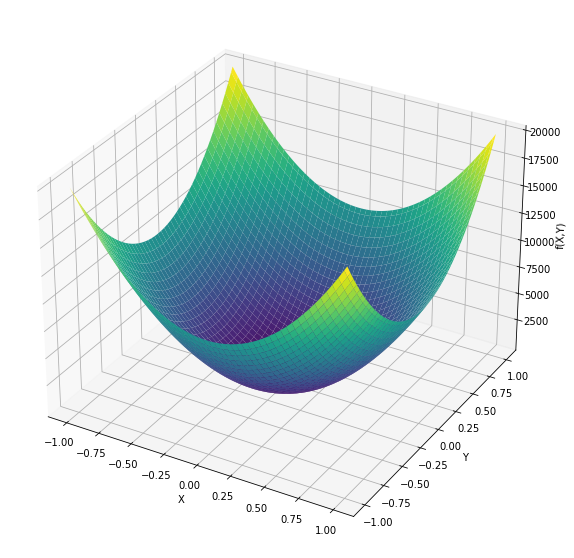

In [35]:
import matplotlib.pyplot as plt
from algorithms import globals

def scale(x):
    a, b = globals.def_clamps
    c, d = globals.original_clamps

    x_scaled = ((x - a) / (b - a)) * (d - c) + c
    return x_scaled

def plot_function(curr_f):
    x = np.linspace(globals.def_clamps[0], globals.def_clamps[1], 100)
    y = np.linspace(globals.def_clamps[0], globals.def_clamps[1], 100)
    X, Y = np.meshgrid(x, y)
    objecitve_f = curr_f

    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            x_clamped = scale(X[i, j])
            y_clamped = scale(Y[i, j])
            Z[i, j] = objecitve_f([x_clamped, y_clamped], 2)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('f(X,Y)') 

    plt.show()

plot_function(test_func)